# # Lecture 2a
# 1. Linear Regression: Theory

# Understanding Linear Regression

**Basic Concept:**

Linear regression is a statistical method used to model the relationship between a dependent variable (y) and one or more independent variables (X). The goal is to find a linear equation that can best predict the dependent variable based on the independent variables.

**Simple vs. Multiple Linear Regression:**

- Simple Linear Regression: Involves one independent variable and one dependent variable, following the formula: y = β0 + β1x + ε.
- Multiple Linear Regression: Involves two or more independent variables. Its formula is y = β0 + β1x1 + β2x2 + ... + βnxn + ε.

**Components of the Linear Equation**

- β0: Intercept, the predicted value of y when all Xs are 0.
- β1, β2, ..., βn: Coefficients representing the impact of each independent variable on the dependent variable.
- x1, x2, ..., xn: Independent variables.
- ε: Error term, representing the difference between the observed and predicted values.

**Interpreting Coefficients**

The coefficient of an independent variable shows how much the dependent variable is expected to increase (or decrease, if the coefficient is negative) when that independent variable increases by one unit, holding all other variables constant.
Example: If β1 is 200 in a housing price model, it means for each additional square foot in size, the price is expected to increase by $200.

**R-squared Value:**

Indicates the proportion of the variance in the dependent variable that is predictable from the independent variables. Higher values suggest a better fit of the model to the data.

Example: An R-squared value of 0.8 in a housing price model suggests that 80% of the variability in housing prices is explained by the model.

**P-Value:**

Helps in determining the statistical significance of each coefficient. A low p-value (usually < 0.05) indicates that the variable is statistically significant in predicting the dependent variable.

Example: A p-value of 0.12 for the size of a house would indicate that size is **NOT** a statistically significant predictor of the house's price.
                         


# Linear Regression Example: Predicting Housing Prices

**Scenario:** Predicting house prices based on size and age.

**Data Variables:**
- `price`: Dependent variable (Price of the house in thousands of dollars).
- `size`: Independent variable (Size of the house in square feet).
- `age`: Independent variable (Age of the house in years).

**Linear Regression Model:**
price = β0 + β1 × size + β2 × age

Where:
- β0 is the intercept.
- β1 is the coefficient for size.
- β2 is the coefficient for age.

**Hypothetical Coefficients (after analysis):**
- β0 = 50 (Intercept)
- β1 = 0.1 (Coefficient for size)
- β2 = -5 (Coefficient for age)

**Regression Equation:**
price = 50 + 0.1 * size - 5 * age

**Example Predictions:**

- **2000 sq ft, 5 years old house:**
  Price = 50 + 0.1 * 2000 - 5 * 5 = 225
  
  Predicted Price: $225,000

- **1500 sq ft, 10 years old house:**
  Price = 50 + 0.1 * 1500 - 5 * 10 = 150

  Predicted Price: $150,000

**Interpretation of Coefficients:**
- β1 = 0.1: Each additional square foot increases price by $100.

- β2 = -5: Each additional year in age decreases price by $5,000.


# 2. Linear Regression: Exercises

### 2.1. Importing data

Q2.1.1. Download the _Staten_Island_housing_market_case.xlsx_ file from Canvas and save it to a folder of your choice. **IMPORTANT! Make sure to save the file under the name "Staten_Island_housing_market_case".** 

Q2.1.2 Once the dataset is saved, upload it to your Google Colab files, using the right most _Upload_ button, as shown in the screenshot below:

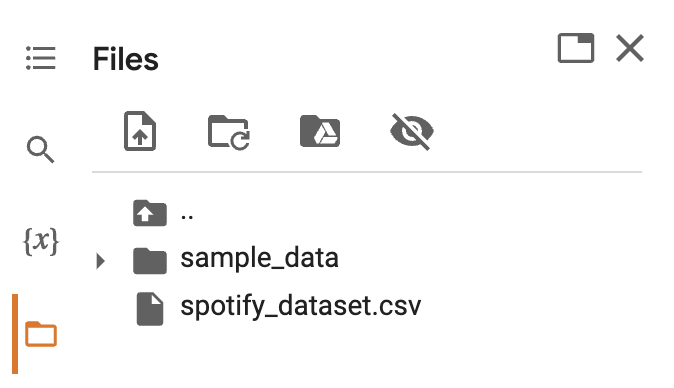



Q2.1.3. Import the pandas and os Python library and read in the _Staten_Island_housing_market_case.xlsx_ file.

In [ ]:
#A2.1.3)
import pandas as pd
import os
staten_island_df = pd.read_excel(os.path.join(os.getcwd(), "Staten_Island_housing_market_case.xlsx"))

Q2.1.4. Having missing values in your dataset is a problem for a lot of statistical and machine learning models. There, let's first get rid of missing values in the dataset by dropping them. Can you tell how many rows were deleted? Hint: use the function dropna() and the function len().

In [ ]:
# Drop all rows with missing values from the dataframe
#A2.1.4)

Q2.1.5. Let's create a smaller subset of the dataframe of the first 50 sold houses and name this new dataframe SI_df_small. We create this smaller dataframe so it will be easier to visualize the results.

In [ ]:
# Create a subset of the first 50 sold houses called 'SI_df_small'
#A2.1.5)

Q2.1.6. Often you need to pre-process the data before you can do the analysis you want. For example by 'engineering' a new feature and adding it to the dataset. If you want to know the effect of the 'age' of a house on 'price', you need to create that variable first. Let's create a new 'age' column in the dataset by subtracting the values in the 'yr_built' column from the 'year' column.

In [ ]:
# Create the variables 'price' and 'age' with this small data set
#A2.1.6)

In [ ]:
# we import the library statsmodels 
import statsmodels.api as sm

"statsmodels (often referred to as sm) is a powerful Python library used for statistical modeling and analysis. One of its key functions is to help us build and understand linear regression models. Linear regression is a way to predict a dependent variable (like 'price') using one or more independent variables (like 'age'). For morel information about statsmodels please see here: https://www.statsmodels.org/stable/index.html

When we create a linear regression model, it's important to include a 'constant' or 'intercept.' This intercept is a starting point for the regression line and represents the expected value of the dependent variable when all independent variables are zero.

In Python, using statsmodels, we add this constant to our model with the sm.add_constant() function. This function essentially adds an additional column of ones to our data, representing the constant. For more information please see here: https://www.statsmodels.org/devel/generated/statsmodels.tools.tools.add_constant.html

Q2.1.7) Create a dataframe called X that includes our independent variable for the regression, and also the constant. In this case, we are interested in understanding how 'age' affects 'price'. So, X will consist of the 'age' data from our dataset and 'const', a column of ones representing the constant. Hint: you need to use the ```sm.add_constant()``` function. 

In [ ]:
#A2.1.7)

In a linear regression model, we have two main types of variables: independent variables and a dependent variable. The independent variables (which we just set up in X) are what we think might influence the dependent variable. The dependent variable is what we are trying to predict or explain.

Now that we have our independent variable X (which includes 'age' and the constant), it's time to identify our dependent variable y. In the context of our study, we want to predict 'price' based on the 'age'. Therefore, please use 'price' as our dependent variable.

Q2.1.8) Create a dependent variable ```y``` and fill it with the values of ```price```.

In [ ]:
#A2.1.8)

We've set up our independent variables X (which includes 'age' and a constant) and our dependent variable y (the 'price'). The next step is to build and train our linear regression model.

This is done with sm.OLS(y, X).fit(), which is a compact but powerful line of code in Python:

- sm.OLS(y, X): This creates the linear regression model using statsmodels. We tell the model that y (house prices) is what we want to predict, and X (ages of the houses, plus a constant) is the data we're using for prediction.

- .fit(): This method 'fits' the model to our data. It calculates the best-fitting line through our data points by minimizing the difference between the observed prices and the prices predicted by our model.

The result, stored in linreg, is our trained model, ready for analysis and prediction. It encapsulates the relationship between the ages of houses and their prices.

After training the model, we use linreg.summary() to get a summary of our model's performance and statistics.

The summary() method provides a detailed report of the model, including:

- The coefficients of the model: These tell us the impact of each independent variable on the dependent variable.
- The R-squared value: This indicates how well our independent variables explain the variation in the dependent variable.
- p-values and confidence intervals for the coefficients: These help us understand the statistical significance of each independent variable.

In [ ]:
linreg = sm.OLS(y, X).fit()
print(linreg.summary())

Q2.1.9. Now that we have the summary of the linear regression of housing price given age, we can interpret the results. Please answer the following questions:

- (A) If 'age' increases by one year, how does that affect the predicted 'price', according to this model?
- (B) Given the intercept and 'age' coefficient, what would be the predicted 'price' for a house that is newly built (age = 0)?
- (C) What does the p-value for 'age' indicate about its significance in predicting 'price'?
- (D) What does the R-squared value inform us about this model's fit?

A2.1.9)

Q2.1.10) The general formula for a linear regression with one variable is: y =  b0 + b1x1:

- y is the predicted variable, in this case price.
- b0 is the intercept.
- b1 is the coefficient or slope of the line for variable x1.
- x1 is the value for variable x1.

Please fill in the intercept, coefficient and x1 value for a house that is 50 years old. Write down this filled formula and explain it. What is the predicted price for this house, according to this model?

A2.1.10)

# 3. Visual understanding of linear regression:

It's always a good idea to have a look at your data to interpret you statistical results, so if it all adds up. In the code that is displayed next we create a scatterplot that displays ```age``` versus ```price```.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming SI_df_small and linreg are already defined as per previous steps

# Plot the "age" and "price" in a scatter plot
plt.scatter(SI_df_small['age'], SI_df_small['price'], color='red')  # s is the size of the points

# Adding titles and labels for clarity
plt.title('Age vs. Price Scatter Plot')
plt.xlabel('Age of House')
plt.ylabel('Price')

# Display the plot
plt.show()


Q3.1 Looking at the scatter plot above, please answer the following questions:

- (A) How would you draw the line that best visualizes the relationship between the two variables?
- (B) How does this work? How does Python find the best line?

A3.1) 

Let's have a look at the regression line in the scatterplot. We redo the plot in a slightly different way as to include the regression line.

In [ ]:
# Plot the "age" and "price" in a scatter plot
plt.scatter(SI_df_small['age'], SI_df_small['price'], color='red')  # s is the size of the points

# To visualize the best-fitting line, you can use seaborn's regplot which combines scatter plot and regression line
sns.regplot(x='age', y='price', data=SI_df_small, scatter=False, color='blue')

# Adding titles and labels for clarity
plt.title('Age vs. Price Scatter Plot with Regression Line')
plt.xlabel('Age of House')
plt.ylabel('Price')

# Display the plot
plt.show()

Q3.2) Looking at the scatterplot with regression line above, answer the following questions:

- (A) Do the intercept and coeffient align with the intercept given in the coefficients table of the regression of questions x?
- (B) What measure does a computer (Python) use to distinguish between a good and badly fitted line?

A3.2)

# 4 Regression with multiple variables

Often regression is performed with many more variables (often called features) to model the more complex relations that can occur in the data. In this case, let's have a look at many more variables and put them in our model, and fit the relationship of all those features on the price of a house. Study the code below and see if it makes sense to you.

In [ ]:
# Assuming staten_island_df is your DataFrame and it's been preprocessed

# Selecting the features for the regression model
features = ['sale_date', 'land_sqft', 'tot_sqft', 'yr_built', 'long', 'lat', 'atm', 'bank', 'bar', 'book_store',
            'bus_station', 'cafe', 'church', 'city_hall', 'doctor', 'fire_station', 'gas_station',
            'gym', 'hospital', 'library', 'lodging', 'mosque', 'movie_theater', 'museum', 'night_club',
            'park', 'parking', 'police', 'restaurant', 'school', 'shopping_mall', 'store', 'supermarket',
            'train_station']

# Adding the constant term for the intercept
X = sm.add_constant(staten_island_df[features])

# Defining the dependent variable
y = staten_island_df['price']

# Fitting the model
multivar_linreg = sm.OLS(y, X).fit()

# Printing the summary of the model
print(multivar_linreg.summary())


Q4.1) Look at the regression table that is outputted above and answer the following questions:

- (A) Which variable has the largest impact on price? How should that be interpreted?
- (B) And which variable has the smallest impact on price? How should that be interpreted?


A4.1)

For an auditor it is important to always interpret coefficients and challenge them. In the regression table it states that for every extra supermarket within 500m, property prices drop by 6395 dollar. Let's run the code below and investigate why this might be the case.

In [ ]:
import matplotlib.pyplot as plt

# Create a figure and a set of subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Scatter plot for price
scatter1 = ax1.scatter(staten_island_df['long'], staten_island_df['lat'], c=staten_island_df['price'], s=0.2, cmap='viridis')
ax1.set_title('Properties by Price')
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')
# Adding a colorbar for the first plot
plt.colorbar(scatter1, ax=ax1, orientation='vertical', label='Price')

# Scatter plot for supermarkets
scatter2 = ax2.scatter(staten_island_df['long'], staten_island_df['lat'], c=staten_island_df['supermarket'], s=0.2, cmap='viridis')
ax2.set_title('Properties by number of Supermarkets within 500m')
ax2.set_xlabel('Longitude')
ax2.set_ylabel('Latitude')
# Adding a colorbar for the second plot
plt.colorbar(scatter2, ax=ax2, orientation='vertical', label='Supermarket Proximity')

# Show the plots
plt.show()

Q4.2) If you take a good look at the two maps. Do you think that the regression coefficient for supermarket makes sense? Why / why not? Based on the maps, why do you think number of supermarkets is negatively correlated with housing price?

A4.2) 

Q4.3) As a auditor for a real estate agency, your task is to identify potential anomalies in property valuations. Using a multivariate linear regression model, you've predicted house prices based on various features. Now, to ensure the accuracy of your model and identify any outliers or unusual cases, you need to examine the houses where the model's predictions deviate significantly from the actual sale prices. Your goal is to find the top 10 houses with the largest differences between the predicted price and the actual sale price, specifically focusing on houses that sold under 100,000 dollars. Look up some of these anomalies on Google Street View using the coordinates. To what extent do these look like houses that sell under 100,000 dollars? What do you think about that as auditor?

We do this by applying the predict() function. What this function does is take the model that was fitted, input the independent variable of choice (in our case here ```X```), and predicts new dependent variables based on the inputted data. 

In [ ]:
# Calculating predicted prices for the entire dataset
staten_island_df['predicted_price'] = multivar_linreg.predict(X)

# Computing the absolute difference between actual and predicted prices
staten_island_df['price_difference'] = abs(staten_island_df['price'] - staten_island_df['predicted_price'])

# Applying the filter for houses priced under $100,000 and sorting the DataFrame based on the differences
# Then selecting the top 10
top_10_differences = staten_island_df[staten_island_df['price'] < 100000].sort_values(by='price_difference', ascending=False).head(10)

# Selecting specific columns for display
top_10_differences = top_10_differences[['lat', 'long', 'price', 'predicted_price', 'price_difference']]

# Displaying the top 10 houses
top_10_differences

A4.3) No real right or wrong answers here, but it seems like these houses are indeed sold under the price.

# 5. KNN: Theory

# Understanding K-Nearest Neighbors (KNN)

**Basic Concept:**

K-Nearest Neighbors (KNN) is a straightforward yet effective algorithm used for classification tasks in machine learning. It predicts the classification of a data point based on the majority class among its nearest neighbors.

**How KNN Works:**

- KNN identifies 'k' closest data points (neighbors) to the new point we want to classify.
- The algorithm then assigns the majority class among these neighbors to the new point.
- The distance between points is typically calculated using Euclidean distance.

**Choosing the Right 'k':**

- **Impact of a Small 'k':**
  - A small 'k' value in KNN makes the model sensitive to noise in the training data, leading to overfitting. Overfitting occurs when the model captures noise and specific patterns of the training data too closely, which may not be generalizable to new, unseen data.

- **Impact of a Large 'k':**
  - Conversely, a large 'k' value tends to smooth the model's predictions, potentially leading to underfitting. Underfitting happens when the model is overly generalized, failing to capture important nuances and patterns in the data, thereby performing poorly on both training and new data.

- **Finding a Balance:**
  - The optimal 'k' value achieves a balance between overfitting and underfitting. It is usually determined through cross-validation, where the model is tested with various 'k' values to find the one that best generalizes to unseen data.


**Importance of Feature Scaling:**

Feature scaling is a crucial preprocessing step in KNN due to the algorithm's reliance on distance calculations for making predictions or classifications.

- **Effect of Different Scales on Distance Calculation:**
  - KNN calculates the distance between data points to find the nearest neighbors. If features are on different scales (for example, one feature ranges from 0 to 1 and another from 0 to 1000), the feature with the larger range will disproportionately influence the distance calculation.
  - This disproportionate influence can lead to biased results because the algorithm might ignore smaller-scaled features, even if they are significant in predicting the outcome.

- **Eliminating Scale Disparity:**
  - Feature scaling eliminates these disparities in scale, ensuring that each feature contributes equally to the distance calculation. This equal contribution is essential for the accurate identification of the nearest neighbors in the feature space.
  - Without scaling, there's a high risk that KNN will yield inaccurate predictions due to its sensitivity to the range of data.

- **Common Scaling Techniques:**
  - **Normalization:** This technique scales all numeric features to a fixed range, typically between 0 and 1. This is done by subtracting the minimum value of each feature and then dividing by the range of the feature. Normalization is particularly useful when the data does not follow a Gaussian distribution.
  - **Standardization:** Standardization transforms the data to have a mean of 0 and a standard deviation of 1. It involves subtracting the mean of each feature and then dividing by the standard deviation. Standardization is less affected by outliers and is often recommended if the data follows a Gaussian distribution.




# 6. KNN: Exercises

As an auditor you have to check the portfolio of a real estate client. You are checking to what extent some houses are eligble for certain tax deductions. One of the things you need to check is if properties labeled as "TWO FAMILY HOMES" are indeed two family homes. Normally you would either check all these rows manually or check a sample and use statistics to determine if your sample findings can be generalized to the population. However, now you learned a new trick to track down the properties that might be mislabeled using machine learning! You will train a KNN model to predict building category classes and check predicted class vs label. The ones where predicted class and label differ, should be checked manually, because they have the highest chance of being wrongly labeled.

Q6.1. First we will visualize the different building categories on two axes: price and total square feet. Looking at the scatter plot, to what extent do you think KNN can be used to correctly predict the building category using price and total square feet?

In [ ]:
# Drop three family homes from the dataset
staten_island_df = staten_island_df[staten_island_df.bldg_ctgy != '03  THREE FAMILY HOMES']

# Creating a scatterplot with price and total square footage, colored by building category
plt.figure(figsize=(10, 6))
sns.scatterplot(data=staten_island_df, x='tot_sqft', y='price', hue='bldg_ctgy', s=5)
plt.title('Property Price vs Total Square Feet by Building Category')
plt.xlabel('Total Square Feet')
plt.ylabel('Price')
plt.show()

A6.1)

Now we want to fit a knn model on the data to investigate how well that method performs. In order to do that, we make use of the sklearn package. 

- _sklearn_: is a package that is used for machine learning in Python. For more information see here: https://scikit-learn.org/stable/
- _KNeighborsClassifier_: contains the knn classifier that we will be using. For more information see here: https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html
- _MinMaxScaler_: is a scaling function that transform features by scaling each feature to a given range. For more information see here: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html
- _classification_report_: Builds a text report showing the main classification metrics. For more information see here: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html
- _confusion_matrix_: Computes a confusion matrix to evaluate the accuracy of a classification. For more information see here: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html
- _fit_transform_: Fits a model to data, then transforms the data. For more information see here: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix

Then we select 'tot_sqft' and 'price' as features to predict building category. Then use normalization (min-max scaling) to scale the features. Please run the code.

In [ ]:
# Selecting relevant features and the target variable
features = ['tot_sqft', 'price']
target = 'bldg_ctgy'

# Filtering the dataset for the two building categories and the selected features
X = staten_island_df[features]
y = staten_island_df[target]

# Normalizing the feature data
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

X_scaled

Q6.2)
A) Why are all scaled features now values between 0 and 1? 
B) Why is it necessary to scale all features before training a KNN model on them?

A6.2)

The code below is used to train a KNN classifier model with 4 neighbors on the scaled data, and then to create a confusion matrix. 

In [ ]:
# Training the KNN model
knn = KNeighborsClassifier(n_neighbors=4)
knn.fit(X_scaled, y)

# Predicting and evaluating the model
y_pred = knn.predict(X_scaled)
conf_matrix = confusion_matrix(y, y_pred)

# The sorted() function sorts the elements of a given iterable in a specific order (ascending or descending) and returns it as a list.
# set() creates a set (and hence removes duplicates)
unique_classes = sorted(set(y))
conf_matrix_df = pd.DataFrame(conf_matrix, index=unique_classes, columns=unique_classes)

# Renaming the index and columns for clarity
conf_matrix_df.index.name = 'Actual'
conf_matrix_df.columns.name = 'Predicted'

conf_matrix_df

Q6.3) 
(A) Looking at the confusion matrix, what do you find? To what extent do you think this model is useable to predict building categories? 
(B) What happens if you take 1 neighbor or 150 neighbors? Why do you think that is?

A6.3)

Q6.4) Visualize predicted building categories vs predicted building categories. Do you see why KNN gets so many predictions wrong?

In [ ]:
# Drop three family homes from the dataset
staten_island_df = staten_island_df[staten_island_df.bldg_ctgy != '03  THREE FAMILY HOMES']

staten_island_df['predicted_bldg_ctgy'] = knn.predict(X_scaled)

# Creating a scatterplot with price and total square footage, colored by building category
plt.figure(figsize=(10, 6))
sns.scatterplot(data=staten_island_df, x='tot_sqft', y='price', hue='bldg_ctgy', s=5)
plt.title('Property Price vs Total Square Feet by Building Category')
plt.xlabel('Total Square Feet')
plt.ylabel('Price')
plt.show()

# Creating a scatterplot with price and total square footage, colored by predicted building category
plt.figure(figsize=(10, 6))
sns.scatterplot(data=staten_island_df, x='tot_sqft', y='price', hue='predicted_bldg_ctgy', s=5)
plt.title('Property Price vs Total Square Feet by Building Category')
plt.xlabel('Total Square Feet')
plt.ylabel('Price')
plt.show()

A6.4)

Q6.5) You want to make sure that no buildings are labeled as 'TWO FAMILY HOMES', while in reality being 'ONE FAMILY HOMES'. Therefore you look at 10 houses that are predicted by KNN to be one family homes based on the data, but are labeled as two family homes. Check some of the houses manually using the coordinates in Google Street View. Do you find any houses that you think are mislabeled? Discuss to what extent this approach offers an alternative to checking everything manually or investigating a sample.

In [ ]:
# Filter for cases where the predicted category is "01 ONE FAMILY HOMES" and the actual category is "02 TWO FAMILY HOMES"
specific_mismatches = staten_island_df[(staten_island_df['predicted_bldg_ctgy'] == '01  ONE FAMILY HOMES') & (staten_island_df['bldg_ctgy'] == '02  TWO FAMILY HOMES')]

# Select the first 10 houses from this specific mismatch
top_10_specific_mismatches = specific_mismatches.head(10)

# Displaying the relevant columns for these 10 houses
print(top_10_specific_mismatches[['lat', 'long', 'bldg_ctgy', 'predicted_bldg_ctgy']])

# staten_island_df.bldg_ctgy.value_counts()

A6.5)